# Test des erstellen Modric-YOLO Modells

### Imports und Modell laden

In [7]:
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

MODEL_PATH = "/data/manser/runs/modric_v1/weights/best.pt"

model = YOLO(MODEL_PATH)

print("Model geladen")

Model geladen


### Bilder testen

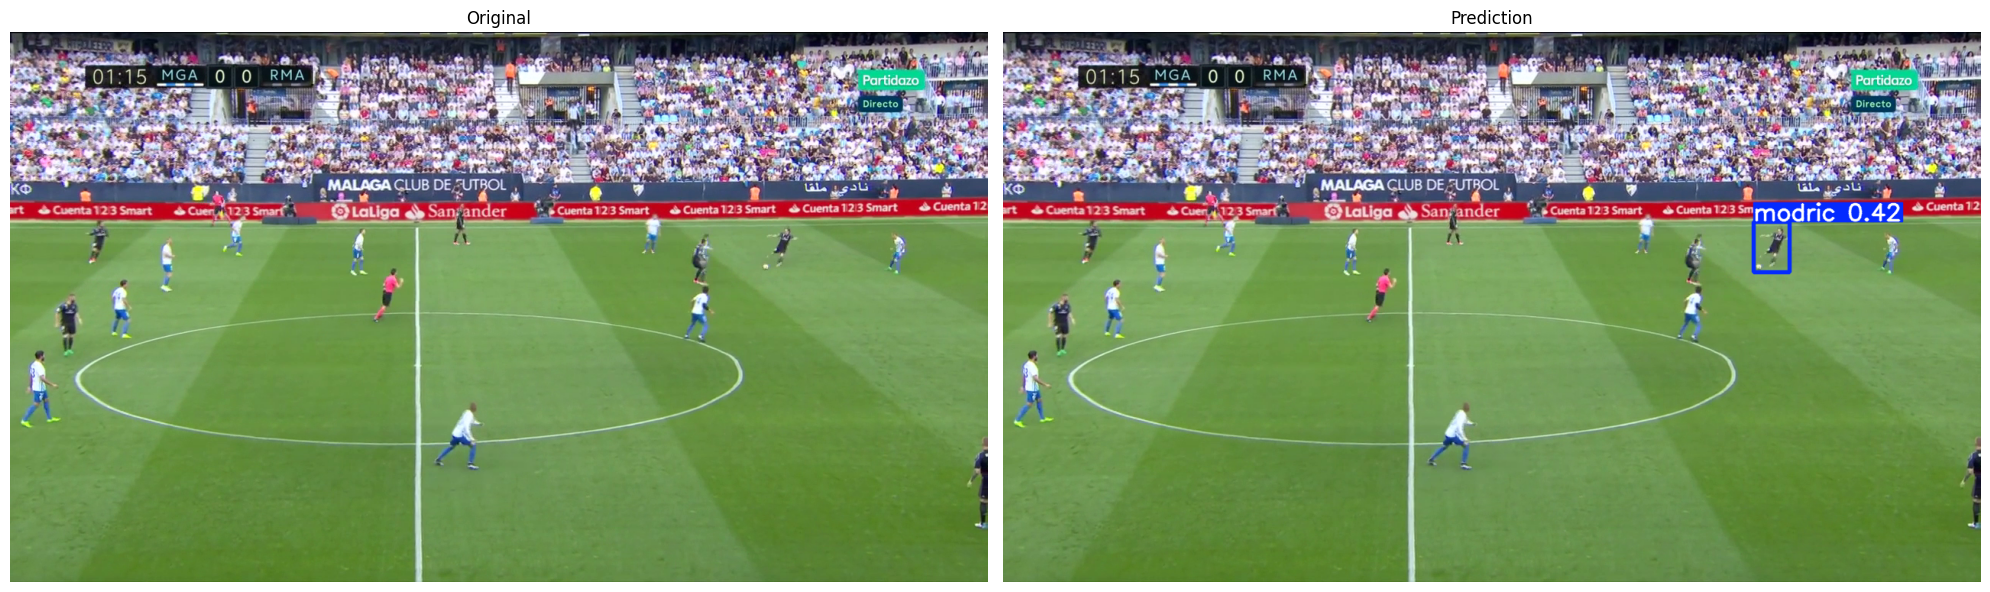

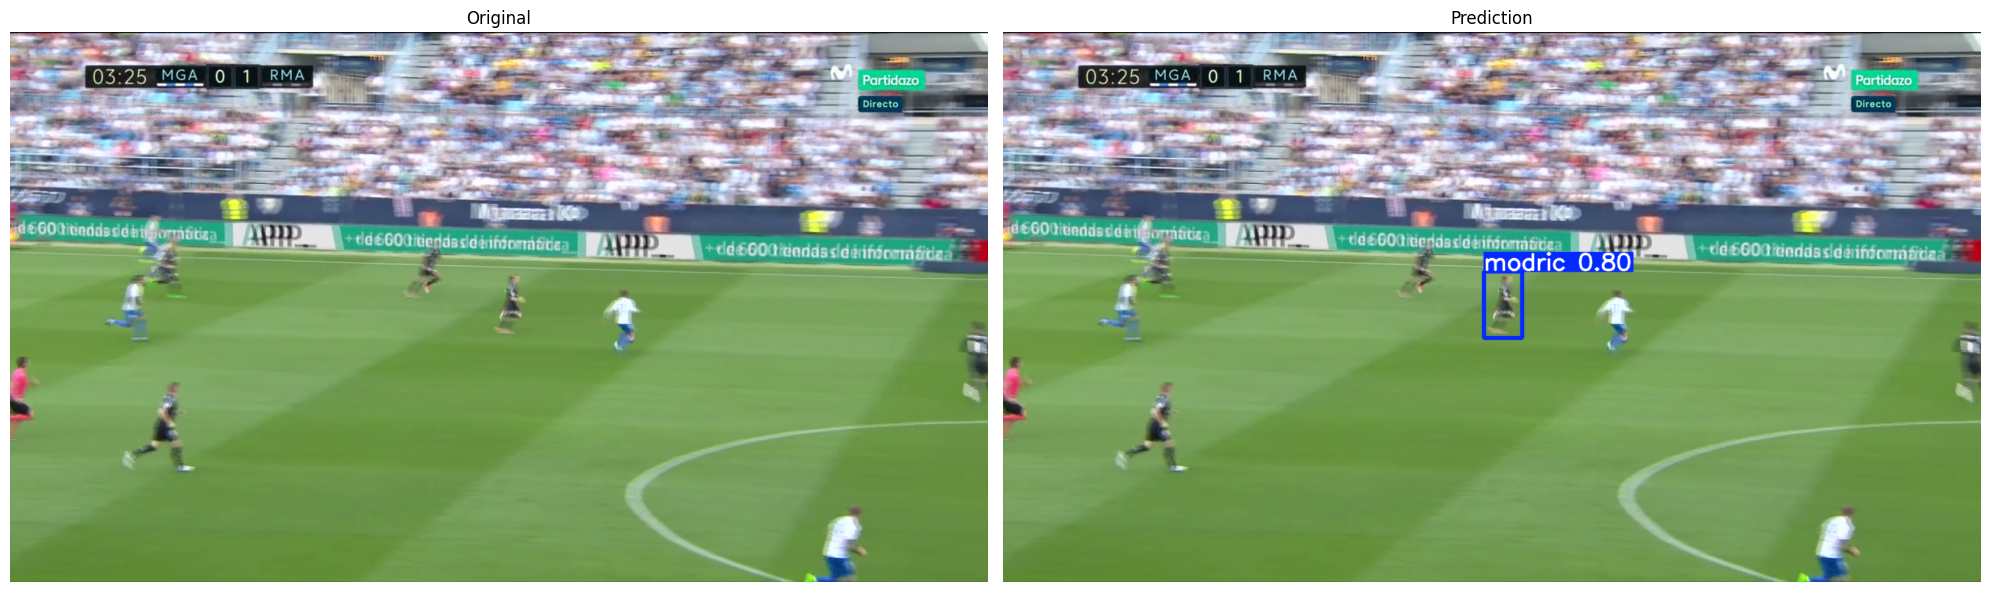

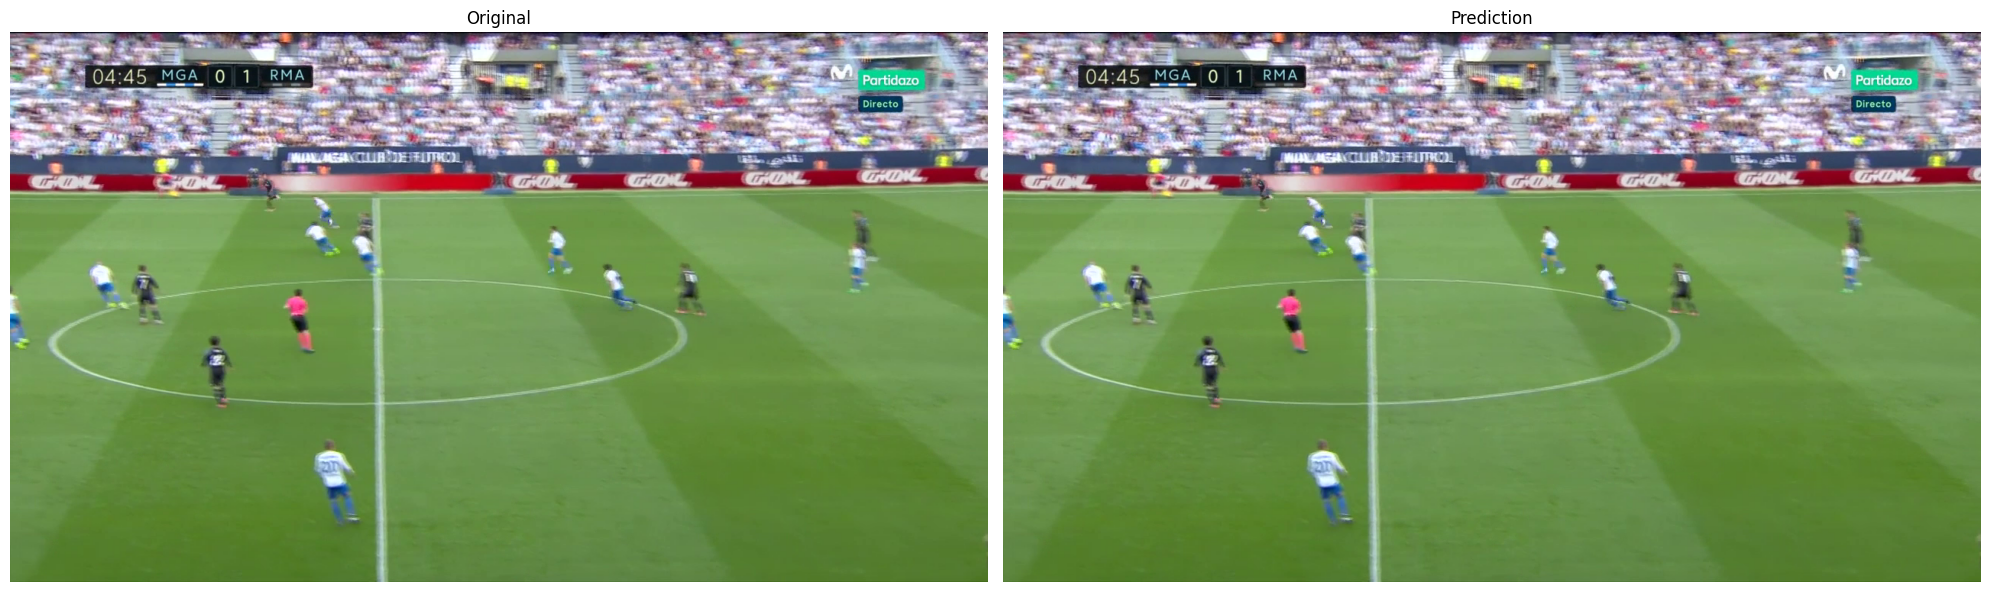

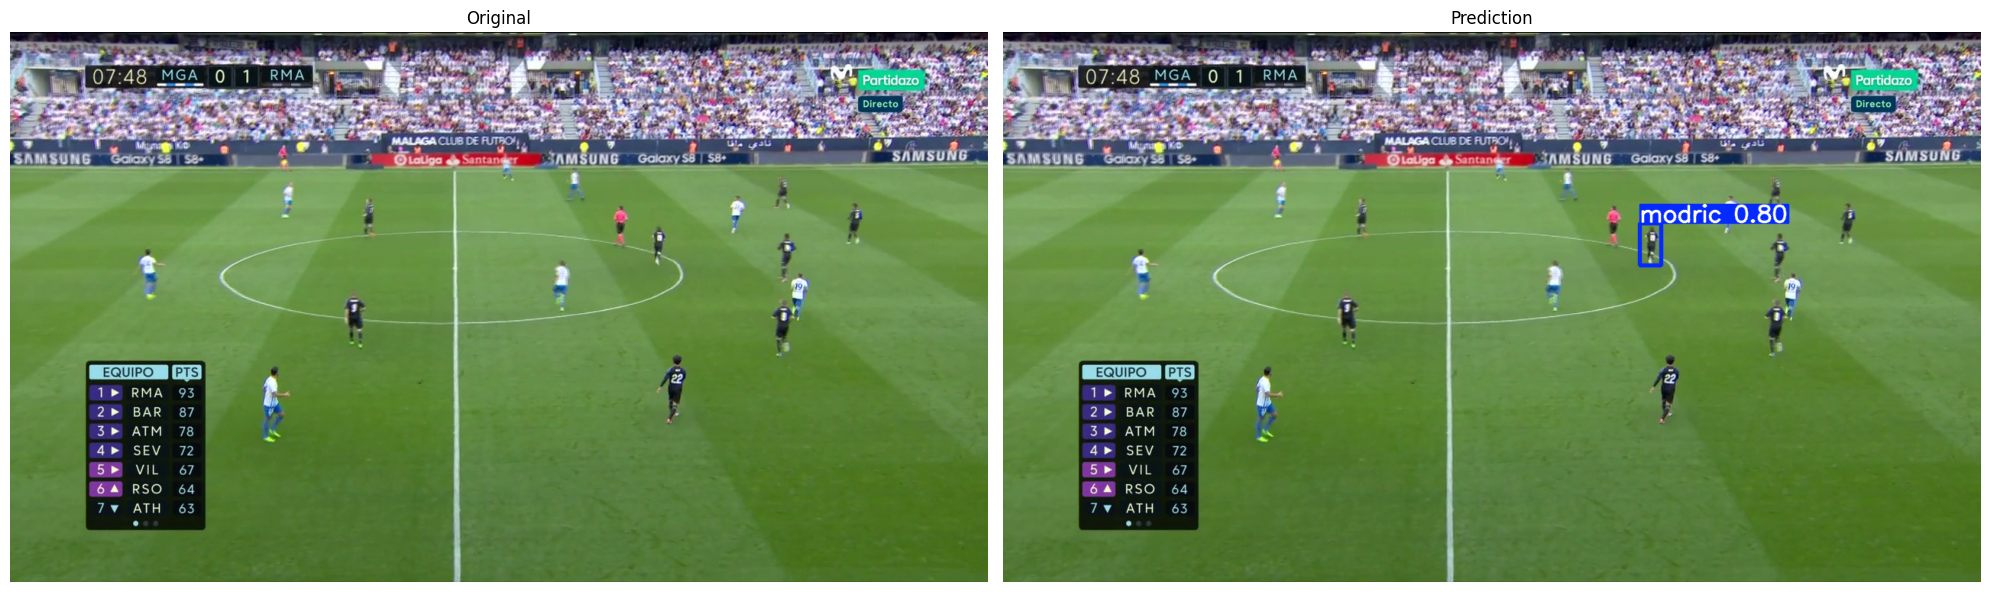

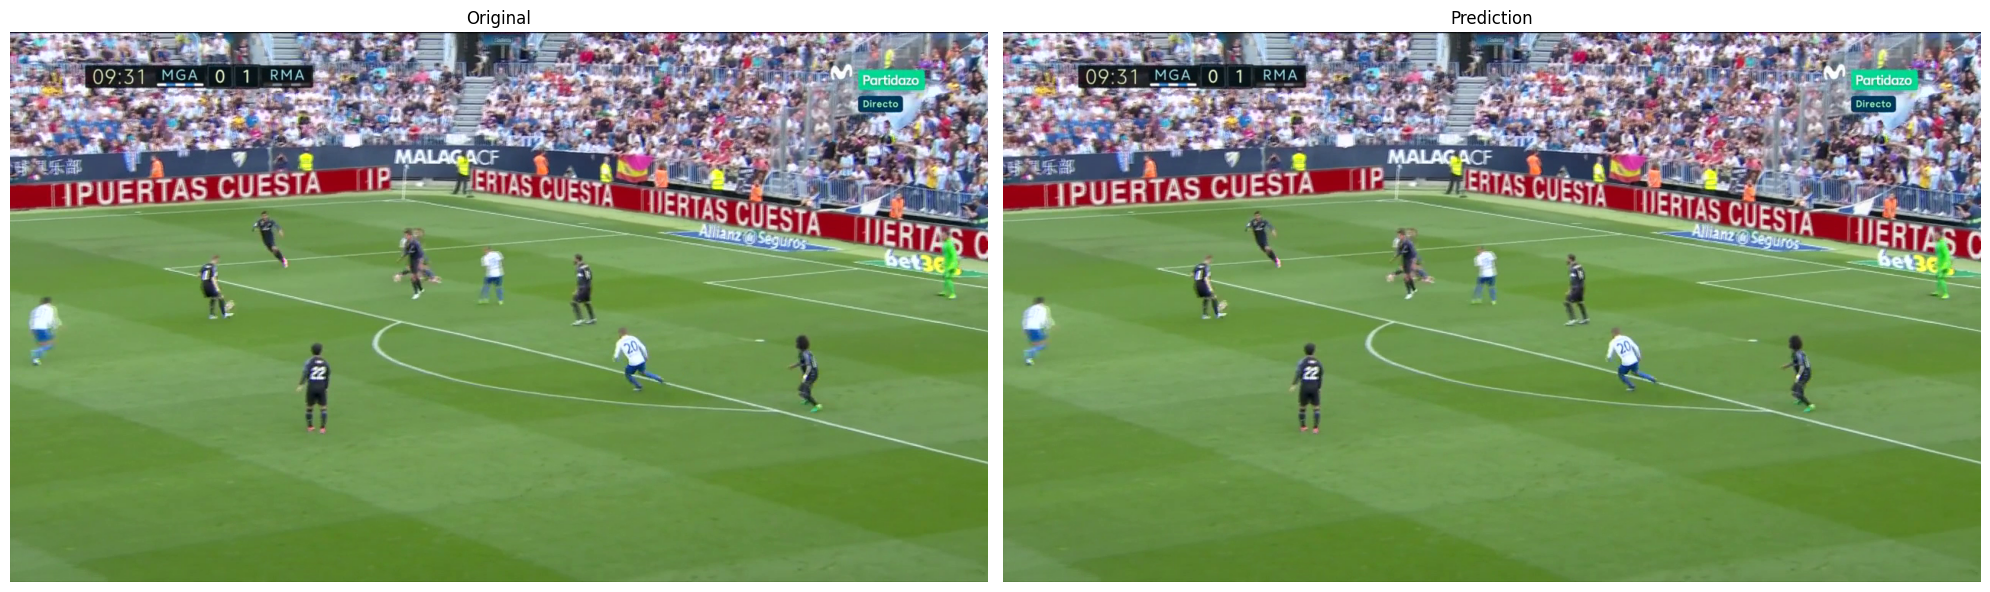

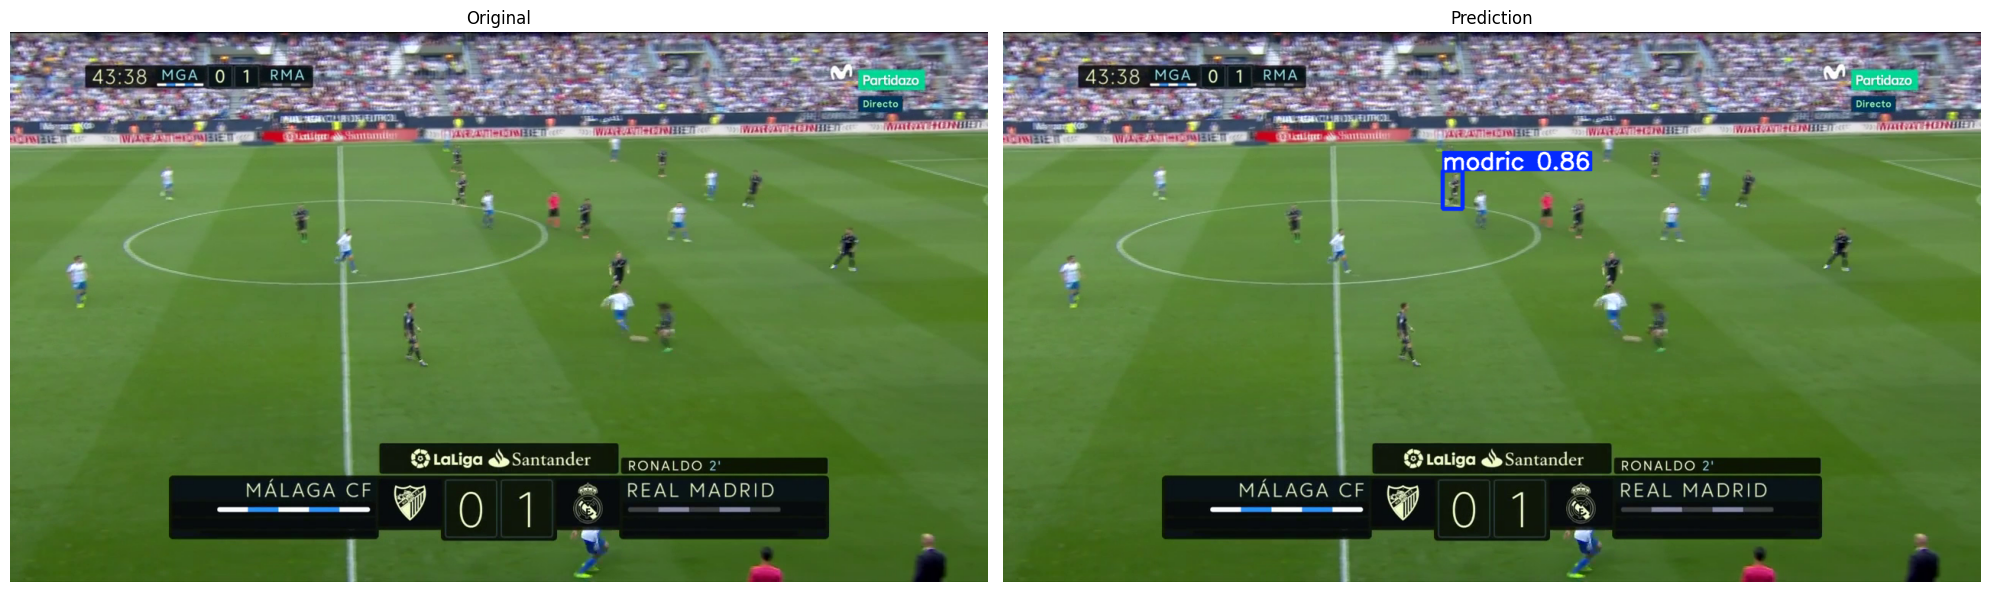

In [19]:
# Ordner mit Testbildern
folder = Path("/data/manser/test_frames")

# Alle Bilder laden
image_paths = sorted(list(folder.glob("*.png")))

for img_path in image_paths:
    # --- Originalbild laden ---
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- Prediction ---
    results = model.predict(
        source=str(img_path),
        conf=0.25,
        imgsz=640,
        device=0,
        verbose=False
    )

    pred_img = results[0].plot()  # Bild mit Bounding Boxen
    pred_img_rgb = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    # --- Plot nebeneinander ---
    plt.figure(figsize=(20, 12))

    # Original
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis("off")

    # Prediction
    plt.subplot(1, 2, 2)
    plt.imshow(pred_img_rgb)
    plt.title("Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()